# Lden transfer — test the Barcelona Lden models on all cities

Applies the Barcelona **Lden** models (from `01_BCN_train_lden.ipynb`) to every city's native Lden target
(`results/<xxx>_lden.csv`), and builds the comparison diagrams. Barcelona = held-out 20% (source); the other
cities are full-segment transfer. Same 18 features, ablation-study palette, legend above each plot.

Caveat carried through: Milan's "Lden" is its diurnal zoning limit (no real Lden); Berlin/Lyon "day" already
was Lden, so their Lden numbers equal their `noise_day`-study numbers.

## Libraries, models, palette

In [1]:
import pandas as pd
import numpy as np
import pickle, os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)

def classify_noise(v):
    if v < 40: return 0
    if v < 50: return 1
    if v < 60: return 2
    if v < 70: return 3
    return 4

M = '../models'
def load(p):
    with open(p,'rb') as f: return pickle.load(f)
scaler = load(f'{M}/Sscaler_lden.pkl'); FEATURES = load(f'{M}/feature_columns_lden.pkl')
class_models = {'Logistic Regression': load(f'{M}/logreg_class_lden.pkl'),
                'XGBoost': load(f'{M}/xgb_class_lden.pkl'),
                'Random Forest': load(f'{M}/rf_class_lden.pkl')}
regre_models = {'Linear Regression': load(f'{M}/linreg_regre_lden.pkl'),
                'XGBoost': load(f'{M}/xgb_regre_lden.pkl'),
                'Random Forest': load(f'{M}/rf_regre_lden.pkl')}

MODEL_COLORS = ['#d58430', '#7251ce', '#144849']
CITY_COLORS = {'Barcelona':'#144849','Viladecans':'#d58430','Milan':'#7251ce',
               'Berlin':'#c44e52','Lyon':'#4c72b0','Zaragoza':'#55a868'}
CITIES = ['Barcelona','Viladecans','Zaragoza','Berlin','Lyon','Milan']
PREFIX = {'Barcelona':'bcn','Viladecans':'vil','Milan':'mil','Berlin':'ber','Lyon':'lyo','Zaragoza':'zgz'}
RES = '../results'; FIG = '../results'; os.makedirs(RES, exist_ok=True)

def load_city(city):
    xxx = PREFIX[city]
    base = '../../../notebooks/_elena/data/bcn' if city=='Barcelona' else f'../../{city}/notebooks/data/{xxx}'
    d = pd.read_csv(base+'_noise_regre_ml_dataset.csv').dropna()
    d['road_id'] = d['road_id'].astype(str)
    l = pd.read_csv(f'{RES}/{xxx}_lden.csv'); l['road_id'] = l['road_id'].astype(str)
    d = d.merge(l, on='road_id', how='inner')
    d['lden_class'] = d['lden_db'].apply(classify_noise)
    return d

## Predict Lden on every city; collect metrics + Lden distributions

In [2]:
class_rows, regre_rows = [], []
lden_db, lden_cls = {}, {}     # for the distribution figures

for city in CITIES:
    d = load_city(city)
    X = scaler.transform(d[FEATURES])
    yc = d['lden_class'].to_numpy(); yr = d['lden_db'].to_numpy(dtype=float)
    if city == 'Barcelona':                       # held-out 20% = source
        idx = np.arange(len(d))
        _, te = train_test_split(idx, test_size=0.2, random_state=42)
        X, yc, yr, d = X[te], yc[te], yr[te], d.iloc[te]
    lden_db[city] = yr; lden_cls[city] = yc

    cls_pred = {'road_id': d['road_id'].values, 'lden_class_true': yc}
    for m, mod in class_models.items():
        yp = mod.predict(X)
        class_rows.append({'city':city,'model':m,'accuracy':accuracy_score(yc,yp),
                           'macro_f1':f1_score(yc,yp,average='macro'),
                           'within_1':np.mean(np.abs(yp-yc)<=1),'signed_err':np.mean(yp-yc)})
        cls_pred[f'pred_{m.split()[0].lower()}'] = yp
    reg_pred = {'road_id': d['road_id'].values, 'lden_db_true': yr}
    for m, mod in regre_models.items():
        yp = np.asarray(mod.predict(X), dtype=float)
        regre_rows.append({'city':city,'model':m,'r2':r2_score(yr,yp),'mae':mean_absolute_error(yr,yp),
                           'rmse':np.sqrt(mean_squared_error(yr,yp)),'signed_err':np.mean(yp-yr)})
        reg_pred[f'pred_{m.split()[0].lower()}'] = yp.round(2)
    pd.DataFrame(cls_pred).to_csv(f'{RES}/{PREFIX[city]}_lden_predictions_class.csv', index=False)
    pd.DataFrame(reg_pred).to_csv(f'{RES}/{PREFIX[city]}_lden_predictions_regre.csv', index=False)
    print('done:', city)

class_cmp = pd.DataFrame(class_rows); regre_cmp = pd.DataFrame(regre_rows)
class_cmp.to_csv(f'{RES}/lden_transfer_comparison_class.csv', index=False)
regre_cmp.to_csv(f'{RES}/lden_transfer_comparison_regre.csv', index=False)
print('saved comparison CSVs')

done: Barcelona
done: Viladecans


done: Zaragoza


done: Berlin


done: Lyon


done: Milan
saved comparison CSVs


### Classification accuracy (Lden) and regression R²

In [3]:
order = CITIES
display(class_cmp.pivot(index='city',columns='model',values='accuracy').reindex(order).round(3))
display(regre_cmp.pivot(index='city',columns='model',values='r2').reindex(order).round(3))

model,Logistic Regression,Random Forest,XGBoost
city,,,
Barcelona,0.614,0.764,0.748
Viladecans,0.537,0.515,0.503
Zaragoza,0.309,0.383,0.436
Berlin,0.232,0.273,0.258
Lyon,0.559,0.559,0.557
Milan,0.437,0.710,0.659


model,Linear Regression,Random Forest,XGBoost
city,,,
Barcelona,0.453,0.708,0.679
Viladecans,0.009,-0.226,-0.444
Zaragoza,-1.179,-0.292,-0.310
Berlin,-0.622,-0.074,-0.152
Lyon,0.211,-0.129,-0.409
Milan,-4.460,-2.036,-2.489


## 1 — Lden distribution (dB) per city

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
data_db = [lden_db[c] for c in CITIES]
parts = ax.violinplot(data_db, showmedians=True, showextrema=False, widths=0.85)
for i, b in enumerate(parts['bodies']):
    b.set_facecolor(CITY_COLORS[CITIES[i]]); b.set_alpha(0.75); b.set_edgecolor('none')
parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(1.3)
ax.scatter(range(1,len(CITIES)+1), [np.mean(d) for d in data_db], color='black', s=18, zorder=3, label='mean')
ax.set_xticks(range(1,len(CITIES)+1)); ax.set_xticklabels(CITIES)
ax.set_ylabel('Lden (dB)')
ax.set_title('Lden distribution by city  (Barcelona = training city)', fontsize=13, fontweight='bold', pad=30)
ax.grid(axis='y', alpha=0.3); ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), frameon=True)
ax.text(0.01, 0.98, 'Milan = diurnal zoning limit (no real Lden);  Berlin/Lyon day already = Lden',
        transform=ax.transAxes, va='top', fontsize=8, style='italic', color='#555')
plt.tight_layout(); plt.savefig(f'{FIG}/fig_lden_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

## 2 — Lden-class share per city

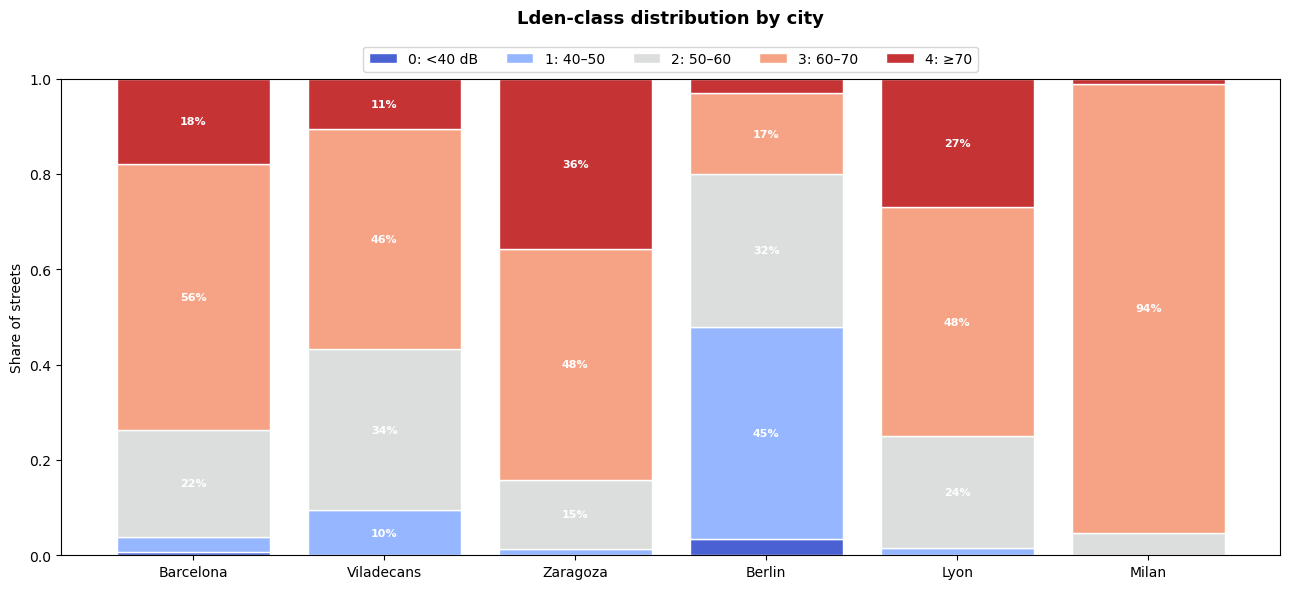

In [5]:
CLASS_LABELS = ['0: <40 dB','1: 40–50','2: 50–60','3: 60–70','4: ≥70']
cc = plt.cm.coolwarm(np.linspace(0.05, 0.95, 5))
shares = np.array([[pd.Series(lden_cls[c]).value_counts(normalize=True).get(k,0.0) for k in range(5)] for c in CITIES])
fig, ax = plt.subplots(figsize=(13, 6)); bottom = np.zeros(len(CITIES))
for k in range(5):
    ax.bar(CITIES, shares[:,k], bottom=bottom, color=cc[k], edgecolor='white', label=CLASS_LABELS[k])
    for j,v in enumerate(shares[:,k]):
        if v>=0.06: ax.text(j, bottom[j]+v/2, f'{v:.0%}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += shares[:,k]
ax.set_ylabel('Share of streets'); ax.set_ylim(0,1)
ax.set_title('Lden-class distribution by city', fontsize=13, fontweight='bold', pad=40)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=5, frameon=True)
plt.tight_layout(); plt.savefig(f'{FIG}/fig_lden_class_share.png', dpi=150, bbox_inches='tight'); plt.show()

## 3 — Transfer: classification vs Barcelona

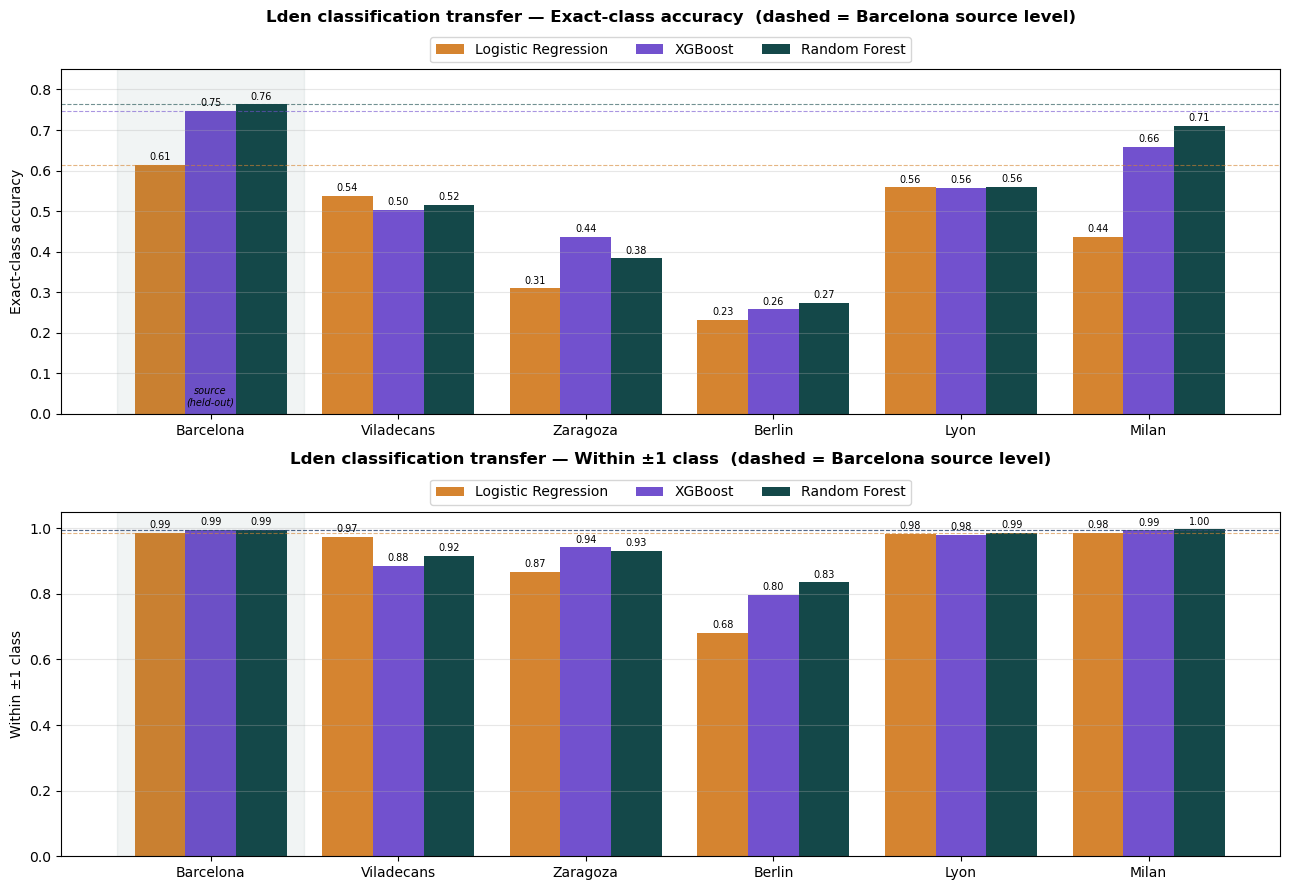

In [6]:
cmodels = ['Logistic Regression','XGBoost','Random Forest']
x = np.arange(len(CITIES)); w = 0.27
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
for metric, ax, title, ylim in [('accuracy', axes[0], 'Exact-class accuracy', (0,0.85)),
                                ('within_1', axes[1], 'Within ±1 class', (0,1.05))]:
    piv = class_cmp.pivot(index='city',columns='model',values=metric).reindex(CITIES)
    for i,m in enumerate(cmodels):
        b = ax.bar(x+(i-1)*w, piv[m].values, w, color=MODEL_COLORS[i], label=m); ax.bar_label(b, fmt='%.2f', fontsize=7, padding=2)
    for i,m in enumerate(cmodels):
        ax.axhline(piv.loc['Barcelona', m], ls='--', lw=0.8, color=MODEL_COLORS[i], alpha=0.6)
    ax.axvspan(-0.5, 0.5, color='#144849', alpha=0.06)
    ax.set_xticks(x); ax.set_xticklabels(CITIES)
    ax.set_title(f'Lden classification transfer — {title}  (dashed = Barcelona source level)', fontsize=12, fontweight='bold', pad=34)
    ax.set_ylabel(title); ax.set_ylim(*ylim); ax.grid(axis='y', alpha=0.3); ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)
axes[0].text(0, 0.02, 'source\n(held-out)', ha='center', fontsize=7, style='italic')
plt.tight_layout(); plt.savefig(f'{FIG}/fig_lden_transfer_classification.png', dpi=150, bbox_inches='tight'); plt.show()

## 4 — Transfer: regression vs Barcelona

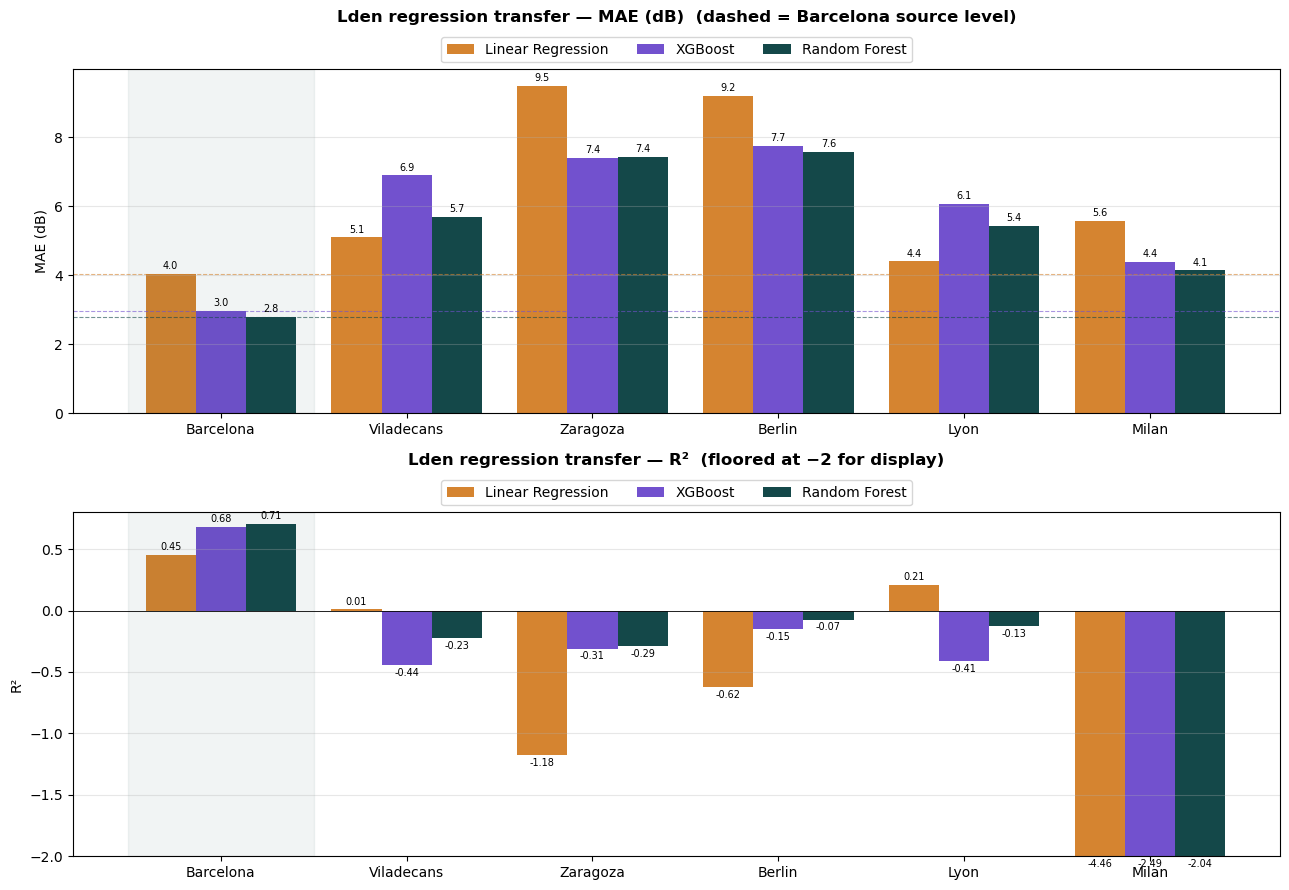

In [7]:
rmodels = ['Linear Regression','XGBoost','Random Forest']
fig, axes = plt.subplots(2, 1, figsize=(13, 9))
# MAE
piv = regre_cmp.pivot(index='city',columns='model',values='mae').reindex(CITIES)
for i,m in enumerate(rmodels):
    b = axes[0].bar(x+(i-1)*w, piv[m].values, w, color=MODEL_COLORS[i], label=m); axes[0].bar_label(b, fmt='%.1f', fontsize=7, padding=2)
for i,m in enumerate(rmodels):
    axes[0].axhline(piv.loc['Barcelona', m], ls='--', lw=0.8, color=MODEL_COLORS[i], alpha=0.6)
axes[0].axvspan(-0.5, 0.5, color='#144849', alpha=0.06)
axes[0].set_xticks(x); axes[0].set_xticklabels(CITIES)
axes[0].set_title('Lden regression transfer — MAE (dB)  (dashed = Barcelona source level)', fontsize=12, fontweight='bold', pad=34)
axes[0].set_ylabel('MAE (dB)'); axes[0].grid(axis='y', alpha=0.3); axes[0].legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)
# R2 floored
floor = -2.0
piv = regre_cmp.pivot(index='city',columns='model',values='r2').reindex(CITIES)
for i,m in enumerate(rmodels):
    true = piv[m].values
    b = axes[1].bar(x+(i-1)*w, [max(t,floor) for t in true], w, color=MODEL_COLORS[i], label=m)
    axes[1].bar_label(b, labels=[f'{t:.2f}' for t in true], fontsize=7, padding=2)
axes[1].axvspan(-0.5, 0.5, color='#144849', alpha=0.06); axes[1].axhline(0, color='k', lw=0.6)
axes[1].set_xticks(x); axes[1].set_xticklabels(CITIES)
axes[1].set_title('Lden regression transfer — R²  (floored at −2 for display)', fontsize=12, fontweight='bold', pad=34)
axes[1].set_ylabel('R²'); axes[1].set_ylim(floor, 0.8); axes[1].grid(axis='y', alpha=0.3); axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)
plt.tight_layout(); plt.savefig(f'{FIG}/fig_lden_transfer_regression.png', dpi=150, bbox_inches='tight'); plt.show()